# **Subcontractor Risk Profiling Model**

This code implements the by calculating risk indicators across financial, safety, performance, compliance, and operational dimensions. Each indicator is converted into a flag or ratio using the logic defined in the updated data model. The script then applies category weightings to compute a final risk score (0–100) for every subcontractor. Statistical models such as K-Means clustering and Isolation Forest are applied to group subcontractors into risk segments and detect unusual risk patterns.

In [ ]:
import pandas as pd
import numpy as np
import re

Financial Flags

In [ ]:
new_data = pd.read_csv("/content/New_finalDataset_Final_Version.csv", encoding='latin1')


cols_to_keep = [
    "company_id",# keep ID for merging later (recommended)
    "company_name",

    "keyMetrics_workingCapital_csi",
    "keyMetrics_netCashFlow_csi",
    "keyMetrics_aggregateTotalCapacity_csi",
    "keyMetrics_largestProject_csi",

    "suretySingleProjectBondingCapacity_csi",
    "suretyAggregateBondingCapacity_csi",

    "bankLineOfCreditTotal_csi",
    "bankLineOfCreditOutstanding_csi",

    "osha300Results_csi",
    "recordableIncidentRates_csi",
    "dartRates_csi",

    "qualification_status_csi",
    "qualification_expiry_date_csi",
    "qualification_internalSingleLimit_csi",
    "qualification_internalTotalLimit_csi",
    "qualification_denialReason_csi",
    "currentEstimatedBacklog_csi",
]

# Keep only available columns to avoid KeyErrors
new_data = new_data[[c for c in cols_to_keep if c in new_data.columns]]

new_data


,company_id,company_name,keyMetrics_workingCapital_csi,keyMetrics_netCashFlow_csi,keyMetrics_aggregateTotalCapacity_csi,keyMetrics_largestProject_csi,suretySingleProjectBondingCapacity_csi,suretyAggregateBondingCapacity_csi,bankLineOfCreditTotal_csi,bankLineOfCreditOutstanding_csi,osha300Results_csi,recordableIncidentRates_csi,dartRates_csi,qualification_status_csi,qualification_expiry_date_csi,qualification_internalSingleLimit_csi,qualification_internalTotalLimit_csi,qualification_denialReason_csi,currentEstimatedBacklog_csi
0,10134,Bergelectric Corp,35727548,0,353914690.0,68940603,100000000,500000000,23000000,20518000,"2021|0|48|21|18|5922603, 2022|0|12|16|39|51521...","2024|1.4224, 2023|2.0523, 2022|2.6008, 2021|2....","2024|0.692, 2023|0.7745, 2022|1.0869, 2021|2.3...",QUALIFIED,2026-10-15T06:00:00.000Z,35000000,NaN,NaN,907935000
1,10305,Partitions & Accessories Co.,4257201,0,24388340.0,845978,2000000,12000000,900000,900000,"2017|0|0|0|1|90679, 2016|0|0|0|1|85741, 2018|0...","2024|0.0, 2023|1.6548, 2022|6.6799, 2021|1.998...","2024|0.0, 2023|1.6548, 2022|1.67, 2021|1.9986,...",QUALIFIED_WITH_EXCEPTIONS,2026-01-03T07:00:00.000Z,850000,NaN,NaN,9800000
2,10356,Sheward & Son & Sons,6094730,0,13263716.0,2022472,2000000,5000000,0,0,"2018|0|0|0|0|84453, 2017|0|0|0|0|85926, 2019|0...","2024|0.0, 2023|0.0, 2022|0.0, 2021|3.6784, 202...","2024|0.0, 2023|0.0, 2022|0.0, 2021|3.6784, 202...",QUALIFIED,2025-11-13T07:00:00.000Z,1500000,NaN,NaN,4141564
3,10446,Kelley Bros of Arizona Inc,11789640,0,132375600.0,1625591,10000000,25000000,7000000,7000000,"2022|0|4|0|3|536515, 2021|0|40|0|4|507027, 202...","2024|2.1321, 2023|0.0, 2022|2.6094, 2021|17.35...","2024|1.4214, 2023|0.0, 2022|1.4911, 2021|15.77...",QUALIFIED,2026-01-14T07:00:00.000Z,1700000,NaN,NaN,97000000
4,10529,Stumbaugh & Associates Inc,3974249,0,34995095.0,1946631,2000000,4000000,2000000,1800000,"2019|0|0|0|0|193873, 2021|0|1|1|1|173385, 2018...","2024|2.3977, 2023|0.0, 2022|0.0, 2021|3.4605, ...","2024|1.1989, 2023|0.0, 2022|0.0, 2021|2.307, 2...",QUALIFIED,2026-03-26T07:00:00.000Z,250000,NaN,NaN,23022478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,151521,SRK Engineering Inc,7494501,0,46833135.0,41000000,25000000,75000000,2500000,2500000,"2019|0|0|0|0|42804, 2020|0|0|0|0|84721, 2021|0...","2024|3.0612, 2023|2.3796, 2022|1.8068, 2021|0....","2024|3.0612, 2023|2.3796, 2022|1.8068, 2021|0....",QUALIFIED,2026-07-02T07:00:00.000Z,8000000,NaN,NaN,25000000
84,153770,Hazard Construction Engr LLC,6886180,2382434,68861800.0,46600000,75000000,200000000,3000000,3000000,"2023|0|1|0|3|193236, 2022|0|2|0|0|160526, 2021...","2024|2.8889, 2023|4.14, 2022|2.4918, 2021|0.0","2024|1.9259, 2023|1.035, 2022|2.4918, 2021|0.0",QUALIFIED,2026-05-12T07:00:00.000Z,8000000,NaN,NaN,94360307
85,153985,Southern Folger Contracting Inc,-568858,0,0.0,7275000,15000000,25000000,2000000,1200000,"2020|0|0|0|0|21046, 2021|0|0|0|0|46000, 2022|0...","2024|0.0, 2023|0.0, 2022|0.0, 2021|0.0, 2020|0.0","2024|0.0, 2023|0.0, 2022|0.0, 2021|0.0, 2020|0.0",QUALIFIED_WITH_EXCEPTIONS,2026-01-09T07:00:00.000Z,250000,NaN,NaN,40514421
86,155575,Panel Built Inc,17859214,0,15927698.0,1918437,0,0,0,0,"2021|0|3|0|2|307100, 2020|0|3|2|3|321630, 2022...","2024|4.4634, 2023|3.2149, 2022|4.3934, 2021|3....","2024|1.2752, 2023|1.4288, 2022|2.9289, 2021|1....",QUALIFIED_WITH_EXCEPTIONS,2026-03-22T07:00:00.000Z,2000000,NaN,NaN,55113162


In [ ]:
# -------------------------
# 1. Single Project Overextension
# -------------------------
largest_project_col = "keyMetrics_largestProject_csi"
bonding_capacity_col = "suretySingleProjectBondingCapacity_csi"
internal_limit_col = "qualification_internalSingleLimit_csi"

new_data[[largest_project_col, bonding_capacity_col, internal_limit_col]] = (
    new_data[[largest_project_col, bonding_capacity_col, internal_limit_col]]
    .apply(pd.to_numeric, errors="coerce")
)

new_data["min_limit_tmp"] = new_data[[bonding_capacity_col, internal_limit_col]].min(axis=1)

new_data["SingleProject_Overextension_Flag"] = np.where(
    new_data[largest_project_col] > new_data["min_limit_tmp"], 1, 0
)

# -------------------------
# 2. Aggregate Overextension
# -------------------------
backlog_col = "currentEstimatedBacklog_csi"
agg_bond_col = "suretyAggregateBondingCapacity_csi"
internal_total_limit_col = "qualification_internalTotalLimit_csi"
aggregate_capacity_col = "keyMetrics_aggregateTotalCapacity_csi"

new_data[[backlog_col, agg_bond_col, internal_total_limit_col, aggregate_capacity_col]] = (
    new_data[[backlog_col, agg_bond_col, internal_total_limit_col, aggregate_capacity_col]]
    .apply(pd.to_numeric, errors="coerce")
)

new_data["agg_min_limit_tmp"] = new_data[
    [agg_bond_col, internal_total_limit_col, aggregate_capacity_col]
].min(axis=1, skipna=True)

new_data["Aggregate_Overextension_Flag"] = np.where(
    (new_data["agg_min_limit_tmp"].notna()) & (new_data[backlog_col] > new_data["agg_min_limit_tmp"]),
    1, 0
)

# -------------------------
# 3. LOC Utilization Score
# -------------------------
total_col = "bankLineOfCreditTotal_csi"
outstanding_col = "bankLineOfCreditOutstanding_csi"

new_data[[total_col, outstanding_col]] = (
    new_data[[total_col, outstanding_col]].apply(pd.to_numeric, errors="coerce")
)

valid_total = new_data[total_col].gt(0)

new_data["LOC_Utilization_Ratio"] = np.where(
    valid_total,
    new_data[outstanding_col] / new_data[total_col],
    np.nan
)

r = new_data["LOC_Utilization_Ratio"]

new_data["LOC_Utilization_Grade"] = np.select(
    [r < 0.40, (r >= 0.40) & (r <= 0.80), r > 0.80],
    [0.0, 0.5, 1.0],
    default=0.0
)

new_data["LOC_Utilization_Score"] = new_data["LOC_Utilization_Grade"]

# -------------------------
# 4. Cash Flow Risk Flag
# -------------------------
cash_flow_col = "keyMetrics_netCashFlow_csi"

new_data[cash_flow_col] = pd.to_numeric(new_data[cash_flow_col], errors="coerce")

new_data["CashFlow_Risk_Flag"] = np.where(
    new_data[cash_flow_col] <= 0, 1, 0
)

# --- Define columns used ---
working_capital_col = "keyMetrics_workingCapital_csi"
backlog_col = "currentEstimatedBacklog_csi"

# --- Ensure numeric values ---
for col in [working_capital_col, backlog_col]:
    new_data[col] = pd.to_numeric(new_data[col], errors="coerce")

# --- Compute ratio safely (avoid divide-by-zero) ---
new_data["WorkingCapital_to_Backlog_Ratio"] = np.where(
    new_data[backlog_col] > 0,
    new_data[working_capital_col] / new_data[backlog_col],
    np.nan
)

# --- Apply grading logic (normalized 0–1) ---
r = new_data["WorkingCapital_to_Backlog_Ratio"]
new_data["WorkingCapital_Coverage_Score"] = np.select(
    [r >= 0.25, (r >= 0.10) & (r < 0.25), r < 0.10],
    [0.0, 0.5, 1.0],
    default=np.nan)
# -------------------------
# Cleanup temp columns
# -------------------------
new_data.drop(columns=["min_limit_tmp", "agg_min_limit_tmp"], inplace=True)

wc_col = "keyMetrics_workingCapital_csi"
bl_col = "currentEstimatedBacklog_csi"

def to_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in {"", "—", "-", "NA", "N/A", "None"}:
        return np.nan
    # handle parentheses negatives and symbols
    s = s.replace("$", "").replace(",", "")
    m = re.match(r"^\((.*)\)$", s)  # (1234) -> -1234
    if m: s = f"-{m.group(1)}"
    try:
        return float(s)
    except:
        return np.nan

new_data[wc_col] = new_data[wc_col].map(to_number)
new_data[bl_col] = new_data[bl_col].map(to_number)

reason = np.select(
    [
        new_data[wc_col].isna() & new_data[bl_col].isna(),
        new_data[wc_col].isna() & new_data[bl_col].notna(),
        new_data[wc_col].notna() & new_data[bl_col].isna(),
        new_data[bl_col].fillna(0) <= 0
    ],
    [
        "missing_both",
        "missing_working_capital",
        "missing_backlog",
        "backlog_zero_or_negative"
    ],
    default="ok"
)
audit = pd.Series(reason).value_counts()
print(audit)

# Using the cleaned new_data from above
ratio = np.where(new_data[bl_col].gt(0), new_data[wc_col] / new_data[bl_col], np.nan)

score = np.select(
    [
        new_data[bl_col].isna() | new_data[bl_col].le(0),         # no/zero backlog
        new_data[wc_col].isna() & new_data[bl_col].gt(0),         # missing WC but positive backlog
        (ratio >= 0.25),
        (ratio >= 0.10) & (ratio < 0.25),
        (ratio < 0.10)
    ],
    [
        0.0,     # treat as low risk (no load to cover)
        0.5,     # neutral when WC missing
        0.0,     # healthy
        0.5,     # moderate
        1.0      # risky
    ],
    default=0.5
)

new_data["WorkingCapital_Coverage_Score"] = score

score_conservative = np.select(
    [
        new_data[bl_col].isna() | new_data[bl_col].le(0),
        new_data[wc_col].isna() & new_data[bl_col].gt(0),
        (ratio >= 0.25),
        (ratio >= 0.10) & (ratio < 0.25),
        (ratio < 0.10)
    ],
    [0.0, 1.0, 0.0, 0.5, 1.0],
    default=1.0
)
new_data["WorkingCapital_Coverage_Score"] = score_conservative

fin_flags = [
    'company_id','company_name','SingleProject_Overextension_Flag', 'Aggregate_Overextension_Flag',
        'LOC_Utilization_Grade', 'CashFlow_Risk_Flag',
        'WorkingCapital_Coverage_Score'
]
new_data[fin_flags]


ok    88
Name: count, dtype: int64


,company_id,company_name,SingleProject_Overextension_Flag,Aggregate_Overextension_Flag,LOC_Utilization_Grade,CashFlow_Risk_Flag,WorkingCapital_Coverage_Score
0,10134,Bergelectric Corp,1,1,1.0,1,1.0
1,10305,Partitions & Accessories Co.,0,0,1.0,1,0.0
2,10356,Sheward & Son & Sons,1,0,0.0,1,0.0
3,10446,Kelley Bros of Arizona Inc,0,1,1.0,1,0.5
4,10529,Stumbaugh & Associates Inc,1,1,1.0,1,0.5
...,...,...,...,...,...,...,...
83,151521,SRK Engineering Inc,1,0,1.0,1,0.0
84,153770,Hazard Construction Engr LLC,1,1,1.0,0,1.0
85,153985,Southern Folger Contracting Inc,1,1,0.5,1,1.0
86,155575,Panel Built Inc,1,1,0.0,1,0.0


In [ ]:
new_data[fin_flags].to_csv("Financial_Flags_final.csv", index=False)

2. Safety Risk

In [ ]:
emr = pd.read_excel("EMR Ratings by Year Dataset (2).xlsx")

emr = emr.copy()
emr["year"] = pd.to_numeric(emr["year"], errors="coerce")
emr["emr_rating"] = pd.to_numeric(emr["emr_rating"], errors="coerce")

emr_sorted = emr.sort_values(["company_id", "year"])
emr_filled = (
    emr_sorted.groupby("company_id", group_keys=False)
              .apply(lambda g: g.sort_values("year").ffill().bfill())
)

emr_latest = (
    emr_filled.sort_values(["company_id", "year"])
              .groupby("company_id", as_index=False)
              .tail(1)[["company_id", "company_name", "year", "emr_rating"]]
              .rename(columns={"year": "latest_year", "emr_rating": "emr_latest"})
)

emr_earliest = (
    emr_filled.sort_values(["company_id", "year"])
              .groupby("company_id", as_index=False)
              .head(1)[["company_id", "emr_rating"]]
              .rename(columns={"emr_rating": "emr_earliest"})
)

final_emr = emr_latest.merge(emr_earliest, on="company_id", how="left")

final_emr["emr_missing_flag"] = np.where(
    final_emr["emr_latest"].isna() | final_emr["emr_earliest"].isna(), 1, 0
)

final_emr["emr_high_flag"] = np.where(final_emr["emr_latest"] > 1, 1, 0)

final_emr["emr_trend_up_flag"] = np.where(
    final_emr["emr_latest"] > final_emr["emr_earliest"], 1, 0
)

final_emr = final_emr[
    ["company_id", "company_name",
     "emr_high_flag", "emr_trend_up_flag", "emr_missing_flag"]
]

print(final_emr.head())

   company_id                                company_name  emr_high_flag  \
0       10000                J. Banicki Construction Inc.              0   
1       10002  Cactus Transport II LLC DBA Cactus Asphalt              0   
2       10005                                     ARB Inc              0   
3       10009                 Magnesite Specialties, Inc.              0   
4       10012          California Sheet Metal Works, Inc.              0   

   emr_trend_up_flag  emr_missing_flag  
0                  0                 0  
1                  1                 0  
2                  0                 0  
3                  1                 0  
4                  1                 0  


/tmp/ipython-input-3857985466.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("year").ffill().bfill())


In [ ]:
final_emr

,company_id,company_name,emr_high_flag,emr_trend_up_flag,emr_missing_flag
0,10000,J. Banicki Construction Inc.,0,0,0
1,10002,Cactus Transport II LLC DBA Cactus Asphalt,0,1,0
2,10005,ARB Inc,0,0,0
3,10009,"Magnesite Specialties, Inc.",0,1,0
4,10012,"California Sheet Metal Works, Inc.",0,1,0
...,...,...,...,...,...
4699,231026,D & S Contractor LLC,0,0,0
4700,231081,D 10 Contracting Inc,0,0,0
4701,231239,SAI,0,0,0
4702,231268,Life Preserve Insulation Llc,0,0,0


In [ ]:
import pandas as pd
import numpy as np

# ------------------------------
# Load your main dataset
# ------------------------------
df = new_data.copy()   # <--- use your dataset name

# ======================================================
# 1. OSHA 300 — Extract latest total cases
# ======================================================
def extract_latest_osha_total(cell):
    if pd.isna(cell):
        return np.nan

    entries = str(cell).split(",")
    year_totals = []

    for entry in entries:
        parts = [p.strip() for p in entry.strip().split("|")]
        if len(parts) != 6:
            continue
        try:
            year = int(parts[0])
            G = float(parts[1])
            H = float(parts[2])
            I = float(parts[3])
            J = float(parts[4])
            total_cases = G + H + I + J
            year_totals.append((year, total_cases))
        except:
            continue

    if not year_totals:
        return np.nan

    latest_year, latest_total = max(year_totals, key=lambda x: x[0])
    return latest_total


df["osha300Results_total_latest"] = df["osha300Results_csi"].apply(extract_latest_osha_total)

df["osha300Results_risk_flag"] = df["osha300Results_total_latest"].apply(
    lambda x: 1 if (pd.isna(x) or x > 5) else 0
)


# ======================================================
# 2. RIR + DART — Extract latest rate
# ======================================================
def extract_latest_rate(cell):
    if pd.isna(cell):
        return np.nan

    pairs = []
    for part in str(cell).split(","):
        if "|" not in part:
            continue
        year_str, val_str = part.split("|")
        try:
            year = int(year_str.strip())
            val = float(val_str.strip())
            pairs.append((year, val))
        except:
            continue

    if not pairs:
        return np.nan

    latest_year, latest_val = max(pairs, key=lambda x: x[0])
    return latest_val


df["recordableIncidentRates_latest"] = df["recordableIncidentRates_csi"].apply(extract_latest_rate)
df["dartRates_latest"] = df["dartRates_csi"].apply(extract_latest_rate)

df["recordableIncidentRates_risk_flag"] = df["recordableIncidentRates_latest"].apply(
    lambda x: 1 if (not pd.isna(x) and x > 3) else 0
)

df["dartRates_risk_flag"] = df["dartRates_latest"].apply(
    lambda x: 1 if (not pd.isna(x) and x > 2) else 0
)


# ======================================================
# 4. BUILD FINAL DATASET
# ======================================================

final_df = df[[
    "company_id",
    "company_name" if "company_name" in df.columns else "CompanyName",


    "osha300Results_risk_flag",


    "recordableIncidentRates_risk_flag",


    "dartRates_risk_flag"
]].copy()

final_df.head()


,company_id,company_name,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag
0,10134,Bergelectric Corp,1,0,0
1,10305,Partitions & Accessories Co.,0,0,0
2,10356,Sheward & Son & Sons,0,0,0
3,10446,Kelley Bros of Arizona Inc,1,0,0
4,10529,Stumbaugh & Associates Inc,0,0,0


In [ ]:
final_df

,company_id,company_name,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag
0,10134,Bergelectric Corp,1,0,0
1,10305,Partitions & Accessories Co.,0,0,0
2,10356,Sheward & Son & Sons,0,0,0
3,10446,Kelley Bros of Arizona Inc,1,0,0
4,10529,Stumbaugh & Associates Inc,0,0,0
...,...,...,...,...,...
83,151521,SRK Engineering Inc,0,1,1
84,153770,Hazard Construction Engr LLC,0,0,0
85,153985,Southern Folger Contracting Inc,0,0,0
86,155575,Panel Built Inc,1,1,0


In [ ]:
safety_flags_final = pd.merge(
    final_df,
    final_emr,
    how="left",
    on = "company_id"
)

safety_flags_final = safety_flags_final.drop(columns=["company_name_y"])
safety_flags_final = safety_flags_final.rename(columns={"company_name_x": "company_name"})

safety_flags_final

,company_id,company_name,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag,emr_high_flag,emr_trend_up_flag,emr_missing_flag
0,10134,Bergelectric Corp,1,0,0,0,1,0
1,10305,Partitions & Accessories Co.,0,0,0,1,1,0
2,10356,Sheward & Son & Sons,0,0,0,0,0,0
3,10446,Kelley Bros of Arizona Inc,1,0,0,0,0,0
4,10529,Stumbaugh & Associates Inc,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
83,151521,SRK Engineering Inc,0,1,1,0,0,0
84,153770,Hazard Construction Engr LLC,0,0,0,0,1,0
85,153985,Southern Folger Contracting Inc,0,0,0,0,0,0
86,155575,Panel Built Inc,1,1,0,0,1,0


In [ ]:
safety_flags_final.to_csv("Safety_Flags_Final.csv")

3. Performance Risk

In [ ]:
rating_cols = [
    "PreconstructionRating", "ProcurementRating", "CompletionStatusRating",
    "SubmittalsAndShopDrawingsRating", "ChangeOrderProcessRating",
    "ScheduleResponseRating", "WorkQualityRating", "SafetyRating",
    "SupervisionRating", "RelentlessHousekeepingRating", "PunchlistRating",
    "CertifiedPayrollRating", "XbeGoalsRating"
]

df = pd.read_excel("Evaluation_Main (2).xlsx")

df[rating_cols] = df[rating_cols].apply(pd.to_numeric, errors="coerce").fillna(3)
df["score"] = df[rating_cols].mean(axis=1)

low_avg = (df["score"] < 3.5).astype(int)
low_individual = (df[rating_cols].min(axis=1) < 3.0).astype(int)
inconsistent = (df[rating_cols].std(axis=1, ddof=0) >= 1.0).astype(int)

Performance_flags = pd.DataFrame({
    "company_id": df["company_id"],
    "low_avg_score_flag": low_avg,
    "low_individual_scores_flag": low_individual,
    "inconsistent_reviews_flag": inconsistent
})

Performance_flags

,company_id,low_avg_score_flag,low_individual_scores_flag,inconsistent_reviews_flag
0,10002,1,0,0
1,10002,1,0,0
2,10009,1,0,0
3,10009,1,1,0
4,10012,1,0,0
...,...,...,...,...
563,187098,1,1,0
564,187098,1,1,0
565,187098,1,0,0
566,187098,1,0,0


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/New_finalDataset_Final_Version.csv", encoding='latin1')

# ---------------------------------
# FIELD SUPERVISION ADEQUACY FLAG
# ---------------------------------
field_col = "numberOfFieldSupervisoryEmployees_csi"
office_col = "numberOfHomeOfficeEmployees_csi"

df[field_col] = pd.to_numeric(df[field_col], errors="coerce")
df[office_col] = pd.to_numeric(df[office_col], errors="coerce")

df["Field_to_Office_Ratio"] = np.where(
    df[office_col] > 0,
    df[field_col] / df[office_col],
    np.nan
)

df["FieldSupervision_Adequacy_Flag"] = np.where(
    df["Field_to_Office_Ratio"] < 0.60,
    1,
    np.where(df["Field_to_Office_Ratio"].notna(), 0, np.nan)
)

# ---------------------------------
# BACKLOG PRESSURE FLAG
# ---------------------------------
backlog_col = "currentEstimatedBacklog_csi"
capacity_col = "keyMetrics_aggregateTotalCapacity_csi"

df[backlog_col] = pd.to_numeric(df[backlog_col], errors="coerce")
df[capacity_col] = pd.to_numeric(df[capacity_col], errors="coerce")

df["Backlog_Utilization"] = np.where(
    df[capacity_col] > 0,
    df[backlog_col] / df[capacity_col],
    np.nan
)

df["BacklogPressure_Flag"] = np.where(
    df["Backlog_Utilization"] > 0.90,
    1,
    np.where(df["Backlog_Utilization"].notna(), 0, np.nan)
)

# ---------------------------------
# DETECT COMPANY ID + COMPANY NAME COLUMN
# ---------------------------------
# Find company_id
id_candidates = [c for c in df.columns if "company_id" in c.lower()]
company_id_col = id_candidates[0] if id_candidates else None

# Find company name
name_candidates = [c for c in df.columns if "companyname" in c.lower() or "company_name" in c.lower()]
company_name_col = name_candidates[0] if name_candidates else None

# ---------------------------------
# BUILD FINAL DATAFRAME
# ---------------------------------
cols = []

if company_id_col:
    cols.append(company_id_col)

if company_name_col:
    cols.append(company_name_col)

cols += ["FieldSupervision_Adequacy_Flag", "BacklogPressure_Flag"]

perfoormance_new_df = df[cols].copy()

# ---------------------------------
# Show Result
# ---------------------------------
print("Final dataset shape:", perfoormance_new_df.shape)
perfoormance_new_df


Final dataset shape: (88, 4)


,company_id,company_name,FieldSupervision_Adequacy_Flag,BacklogPressure_Flag
0,10134,Bergelectric Corp,0.0,1.0
1,10305,Partitions & Accessories Co.,0.0,0.0
2,10356,Sheward & Son & Sons,0.0,0.0
3,10446,Kelley Bros of Arizona Inc,1.0,0.0
4,10529,Stumbaugh & Associates Inc,0.0,0.0
...,...,...,...,...
83,151521,SRK Engineering Inc,0.0,0.0
84,153770,Hazard Construction Engr LLC,0.0,1.0
85,153985,Southern Folger Contracting Inc,0.0,NaN
86,155575,Panel Built Inc,1.0,1.0


In [ ]:
performance_flags_final = pd.merge(
    perfoormance_new_df,
    Performance_flags,
    how="left",
    on = "company_id"
)

# performance_flags_final = performance_flags_final.drop(columns=["company_name_y"])
# performance_flags_final = performance_flags_final.rename(columns={"company_name_x": "company_name"})

performance_flags_final

,company_id,company_name,FieldSupervision_Adequacy_Flag,BacklogPressure_Flag,low_avg_score_flag,low_individual_scores_flag,inconsistent_reviews_flag
0,10134,Bergelectric Corp,0.0,1.0,1,1,0
1,10134,Bergelectric Corp,0.0,1.0,1,1,0
2,10134,Bergelectric Corp,0.0,1.0,1,1,0
3,10305,Partitions & Accessories Co.,0.0,0.0,1,0,0
4,10305,Partitions & Accessories Co.,0.0,0.0,1,0,0
...,...,...,...,...,...,...,...
214,153770,Hazard Construction Engr LLC,0.0,1.0,1,0,0
215,153985,Southern Folger Contracting Inc,0.0,NaN,1,1,0
216,155575,Panel Built Inc,1.0,1.0,1,0,0
217,155575,Panel Built Inc,1.0,1.0,1,1,0


In [ ]:
performance_flags_final = performance_flags_final.drop_duplicates(subset=["company_id"], keep="first").reset_index(drop=True)
performance_flags_final


,company_id,company_name,FieldSupervision_Adequacy_Flag,BacklogPressure_Flag,low_avg_score_flag,low_individual_scores_flag,inconsistent_reviews_flag
0,10134,Bergelectric Corp,0.0,1.0,1,1,0
1,10305,Partitions & Accessories Co.,0.0,0.0,1,0,0
2,10356,Sheward & Son & Sons,0.0,0.0,1,0,0
3,10446,Kelley Bros of Arizona Inc,1.0,0.0,1,0,0
4,10529,Stumbaugh & Associates Inc,0.0,0.0,1,0,0
...,...,...,...,...,...,...,...
83,151521,SRK Engineering Inc,0.0,0.0,1,0,0
84,153770,Hazard Construction Engr LLC,0.0,1.0,1,1,0
85,153985,Southern Folger Contracting Inc,0.0,NaN,1,1,0
86,155575,Panel Built Inc,1.0,1.0,1,0,0


In [ ]:
performance_flags_final.to_csv("Performance_Flags_Final.csv")

4. Compliance & Licensing

In [ ]:
import pandas as pd
from datetime import datetime

roc = pd.read_csv("ROC_Posting-List_2025-09-03.csv")

def clean(x):
    return str(x).upper().strip()

roc = roc.copy()
roc["Business Name"] = roc["Business Name"].apply(clean)

roc_unique = roc.sort_values("Business Name").groupby("Business Name", as_index=False).first()

final = pd.DataFrame()

final["Business Name"] = roc_unique["Business Name"]

final["unlicensed_flag"] = roc_unique["License No"].apply(
    lambda x: 1 if pd.isna(x) or str(x).strip()=="" else 0
)

roc_unique["Expiration Date"] = pd.to_datetime(
    roc_unique["Expiration Date"], errors="coerce"
)
today = pd.Timestamp.today()

final["expired_qualification_flag"] = roc_unique["Expiration Date"].apply(
    lambda d: 1 if pd.notnull(d) and d < today else 0
)

roc_unique["Status"] = roc_unique["Status"].astype(str).str.upper().str.strip()

final["denied_or_suspended_flag"] = roc_unique["Status"].apply(
    lambda s: 1 if s in ["DENIED", "SUSPENDED"] else 0
)

final = final.drop_duplicates().reset_index(drop=True)
final = final.rename(columns={"Business Name": "company_name"})
final
final.to_csv("Compliance_Flags_Final.csv")

/tmp/ipython-input-3067023496.py:4: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  roc = pd.read_csv("ROC_Posting-List_2025-09-03.csv")
/tmp/ipython-input-3067023496.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  roc_unique["Expiration Date"] = pd.to_datetime(


5. Operational & Trade Risk

In [ ]:
import pandas as pd
import numpy as np
import re

# ============================================
# 1. LOAD INPUT FILES
# ============================================

PREQUAL_PATH = "/content/Prequalification_Datasets (1).xlsx"
WORK_PATH    = "/content/Subcontractor_Work_History (1).xlsx"
CSI_PATH     = "/content/CSI Trade Type Dataset (2).xlsx"

prequal = pd.read_excel(PREQUAL_PATH, dtype={"company_id": str})
wh      = pd.read_excel(WORK_PATH, dtype={"company_id": str})
csi     = pd.read_excel(CSI_PATH, dtype=str)

# ============================================
# 2. CLEAN & NORMALIZE WORK HISTORY + PREQUAL
# (Needed to compute OverloadScore_0_1)
# ============================================

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("$", "").replace(",", "")
    if s == "":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

prequal["LargestProject"] = prequal["LargestProject"].apply(parse_money)

# Work history date column
if "order_date" in wh.columns:
    wh["order_date"] = pd.to_datetime(wh["order_date"], errors="coerce")
else:
    wh["order_date"] = pd.NaT

# Identify a "contract amount" column automatically
def find_contract_column(cols):
    for c in cols:
        if re.search(r"(contract|amount|value|sum|award|subcontract)", c, flags=re.I):
            return c
    return None

amount_col = find_contract_column(wh.columns)

# If amount column missing — fallback to counts
if amount_col:
    wh[amount_col] = wh[amount_col].apply(parse_money)

# Filter active recent jobs (last 12 months)
if "order_date" in wh.columns:
    max_date = wh["order_date"].max()
    cutoff = max_date - pd.DateOffset(months=12)
    wh_active = wh[wh["order_date"] >= cutoff].copy()
else:
    wh_active = wh.copy()

# --------------------------------------------
# Compute OverloadScore_0_1
# --------------------------------------------

if amount_col:
    active_sum = (
        wh_active.groupby("company_id")[amount_col]
        .sum()
        .reset_index()
        .rename(columns={amount_col: "TotalActiveContractedValue"})
    )

    overload_df = prequal.merge(active_sum, on="company_id", how="left")

    overload_df["OverloadRatio"] = (
        overload_df["TotalActiveContractedValue"] / overload_df["LargestProject"]
    )

    overload_df["OverloadScore_0_1"] = (
        overload_df["OverloadRatio"].clip(lower=0, upper=2.0) / 2.0
    ).fillna(0)

else:
    # Fallback: No contract amounts → not risky
    overload_df = prequal[["company_id"]].copy()
    overload_df["OverloadScore_0_1"] = 0

overload_df = overload_df[["company_id", "OverloadScore_0_1"]].copy()

# ============================================
# 3. CREATE TRADE TYPE RISK (trade_risk12_final)
# ============================================

csi["trade_division"] = csi["trade_type"].str.extract(r"^(\d{2})")

DIV_MAP = {
    "00": 0.20, "01": 0.20,
    "02": 0.60,
    "03": 0.70, "04": 0.70,
    "05": 0.85,
    "06": 0.60,
    "07": 0.50,
    "08": 0.45,
    "09": 0.35, "10": 0.35, "11": 0.35, "12": 0.35, "13": 0.35, "14": 0.35,
    "21": 0.80, "22": 0.80, "23": 0.80,
    "25": 0.80, "27": 0.80, "28": 0.80,
    "26": 0.90,
    "31": 0.70, "32": 0.70, "33": 0.70, "34": 0.70, "35": 0.70,
}

def get_trade_risk(div):
    if pd.isna(div):
        return 0.50
    return DIV_MAP.get(div, 0.50)

csi["trade_risk12"] = csi["trade_division"].apply(get_trade_risk)

trade_df = (
    csi.groupby("company_id")["trade_risk12"]
    .max()           # worst-case risk
    .reset_index()
    .rename(columns={"trade_risk12": "trade_risk12_final"})
)

# ============================================
# 4. MERGE OVERLOAD + TRADE RISK
# ============================================

merged = overload_df.merge(trade_df, on="company_id", how="outer")

# Drop rows without company_id
merged = merged.dropna(subset=["company_id"]).copy()
merged["company_id"] = merged["company_id"].astype(str)

# Fill missing scores
merged["OverloadScore_0_1"] = merged["OverloadScore_0_1"].fillna(0)
merged["trade_risk12_final"] = merged["trade_risk12_final"].fillna(0)

# ============================================
# 5. CREATE FINAL FLAGS (LOGIC FROM PICTURE)
# ============================================

# Overloaded Vendor Flag:
# If total contracted amount exceeds 80% → 1
merged["overloaded_vendor_flag"] = np.where(
    merged["OverloadScore_0_1"] >= 0.80,   # ≥80% capacity
    1, 0
)

# Trade Risk Flag:
# High-risk trades = ≥0.70
merged["trade_risk12_flag"] = np.where(
    merged["trade_risk12_final"] >= 0.70,
    1, 0
)

# Final formatting
merged["overloaded_vendor_flag"] = merged["overloaded_vendor_flag"].astype(int)
merged["trade_risk12_flag"] = merged["trade_risk12_flag"].astype(int)

# ============================================
# 6. SHOW FINAL OUTPUT
# ============================================

print("FINAL MERGED DATASET:")
display(merged.head())
print("Shape:", merged.shape)


FINAL MERGED DATASET:


,company_id,OverloadScore_0_1,trade_risk12_final,overloaded_vendor_flag,trade_risk12_flag
0,10000,0,0.70,0,1
1,10002,0,0.70,0,1
2,100020,0,0.35,0,0
3,100049,0,0.60,0,0
4,100056,0,0.85,0,1


Shape: (3273, 5)


In [ ]:
merged[['company_id','overloaded_vendor_flag','trade_risk12_flag']].to_csv('Operational_&_Trade_flag_final.csv')

Merging Financial and Safety flags

In [ ]:
financial_flagss = pd.read_csv("/content/Financial_Flags_final.csv")
safety_flagss = pd.read_csv("/content/Safety_Flags_Final.csv")
performance_flagss = pd.read_csv("/content/Performance_Flags_Final.csv")

FS_final = pd.merge(
    financial_flagss,
    safety_flagss,
    how="left",
    on = "company_id"
)

FS_final[['company_id', 'company_name_x', 'SingleProject_Overextension_Flag',
       'Aggregate_Overextension_Flag', 'LOC_Utilization_Grade',
       'CashFlow_Risk_Flag', 'WorkingCapital_Coverage_Score', 'osha300Results_risk_flag',
       'recordableIncidentRates_risk_flag', 'dartRates_risk_flag',
       'emr_high_flag', 'emr_trend_up_flag', 'emr_missing_flag']]
FS_final = FS_final.drop(columns=['company_name_y'])
FS_final = FS_final.drop(columns=['Unnamed: 0'])
FS_final = FS_final.rename(columns={"company_name_x": "company_name"})
FS_final


,company_id,company_name,SingleProject_Overextension_Flag,Aggregate_Overextension_Flag,LOC_Utilization_Grade,CashFlow_Risk_Flag,WorkingCapital_Coverage_Score,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag,emr_high_flag,emr_trend_up_flag,emr_missing_flag
0,10134,Bergelectric Corp,1,1,1.0,1,1.0,1,0,0,0,1,0
1,10305,Partitions & Accessories Co.,0,0,1.0,1,0.0,0,0,0,1,1,0
2,10356,Sheward & Son & Sons,1,0,0.0,1,0.0,0,0,0,0,0,0
3,10446,Kelley Bros of Arizona Inc,0,1,1.0,1,0.5,1,0,0,0,0,0
4,10529,Stumbaugh & Associates Inc,1,1,1.0,1,0.5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,151521,SRK Engineering Inc,1,0,1.0,1,0.0,0,1,1,0,0,0
84,153770,Hazard Construction Engr LLC,1,1,1.0,0,1.0,0,0,0,0,1,0
85,153985,Southern Folger Contracting Inc,1,1,0.5,1,1.0,0,0,0,0,0,0
86,155575,Panel Built Inc,1,1,0.0,1,0.0,1,1,0,0,1,0


In [ ]:
performance_flagss = pd.read_csv("/content/Performance_Flags_Final.csv")

FSP_final = pd.merge(
    FS_final,
    performance_flagss,
    how="left",
    on = "company_id"
)


In [ ]:
FSP_final = FSP_final.drop(columns=['Unnamed: 0_y'], errors='ignore')
FSP_final = FSP_final.drop(columns=['company_name_y'], errors='ignore')
FSP_final = FSP_final.rename(columns={"company_name_x": "company_name"})
FSP_final

,company_id,company_name,SingleProject_Overextension_Flag,Aggregate_Overextension_Flag,LOC_Utilization_Grade,CashFlow_Risk_Flag,WorkingCapital_Coverage_Score,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag,...,BacklogPressure_Flag_x,low_avg_score_flag_x,low_individual_scores_flag_x,inconsistent_reviews_flag_x,company_name,FieldSupervision_Adequacy_Flag_y,BacklogPressure_Flag_y,low_avg_score_flag_y,low_individual_scores_flag_y,inconsistent_reviews_flag_y
0,10134,Bergelectric Corp,1,1,1.0,1,1.0,1,0,0,...,1.0,1,1,0,Bergelectric Corp,0.0,1.0,1,1,0
1,10305,Partitions & Accessories Co.,0,0,1.0,1,0.0,0,0,0,...,0.0,1,0,0,Partitions & Accessories Co.,0.0,0.0,1,0,0
2,10356,Sheward & Son & Sons,1,0,0.0,1,0.0,0,0,0,...,0.0,1,0,0,Sheward & Son & Sons,0.0,0.0,1,0,0
3,10446,Kelley Bros of Arizona Inc,0,1,1.0,1,0.5,1,0,0,...,0.0,1,0,0,Kelley Bros of Arizona Inc,1.0,0.0,1,0,0
4,10529,Stumbaugh & Associates Inc,1,1,1.0,1,0.5,0,0,0,...,0.0,1,0,0,Stumbaugh & Associates Inc,0.0,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,151521,SRK Engineering Inc,1,0,1.0,1,0.0,0,1,1,...,0.0,1,0,0,SRK Engineering Inc,0.0,0.0,1,0,0
84,153770,Hazard Construction Engr LLC,1,1,1.0,0,1.0,0,0,0,...,1.0,1,1,0,Hazard Construction Engr LLC,0.0,1.0,1,1,0
85,153985,Southern Folger Contracting Inc,1,1,0.5,1,1.0,0,0,0,...,NaN,1,1,0,Southern Folger Contracting Inc,0.0,NaN,1,1,0
86,155575,Panel Built Inc,1,1,0.0,1,0.0,1,1,0,...,1.0,1,0,0,Panel Built Inc,1.0,1.0,1,0,0


In [ ]:
operational_trade_flags = pd.read_csv('/content/Operational_&_Trade_flag_final.csv')

FSPOT_final = pd.merge(
    FSP_final,
    operational_trade_flags,
    how="left",
    on="company_id"
)

# Fix: Ensure FSPOT_final has only unique column names, keeping the first occurrence if duplicates exist.
FSPOT_final = FSPOT_final.loc[:,~FSPOT_final.columns.duplicated()]

# Drop any remaining 'Unnamed' columns from previous merges/reads that might be left due to the deduplication
FSPOT_final = FSPOT_final.drop(columns=[col for col in FSPOT_final.columns if 'Unnamed:' in col], errors='ignore')

print("Columns after deduplication in FSPOT_final:")
print(FSPOT_final.columns)

FSPOT_final

Columns after deduplication in FSPOT_final:
Index(['company_id', 'company_name', 'SingleProject_Overextension_Flag',
       'Aggregate_Overextension_Flag', 'LOC_Utilization_Grade',
       'CashFlow_Risk_Flag', 'WorkingCapital_Coverage_Score',
       'osha300Results_risk_flag', 'recordableIncidentRates_risk_flag',
       'dartRates_risk_flag', 'emr_high_flag', 'emr_trend_up_flag',
       'emr_missing_flag', 'FieldSupervision_Adequacy_Flag_x',
       'BacklogPressure_Flag_x', 'low_avg_score_flag_x',
       'low_individual_scores_flag_x', 'inconsistent_reviews_flag_x',
       'FieldSupervision_Adequacy_Flag_y', 'BacklogPressure_Flag_y',
       'low_avg_score_flag_y', 'low_individual_scores_flag_y',
       'inconsistent_reviews_flag_y', 'overloaded_vendor_flag',
       'trade_risk12_flag'],
      dtype='object')


,company_id,company_name,SingleProject_Overextension_Flag,Aggregate_Overextension_Flag,LOC_Utilization_Grade,CashFlow_Risk_Flag,WorkingCapital_Coverage_Score,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag,...,low_avg_score_flag_x,low_individual_scores_flag_x,inconsistent_reviews_flag_x,FieldSupervision_Adequacy_Flag_y,BacklogPressure_Flag_y,low_avg_score_flag_y,low_individual_scores_flag_y,inconsistent_reviews_flag_y,overloaded_vendor_flag,trade_risk12_flag
0,10134,Bergelectric Corp,1,1,1.0,1,1.0,1,0,0,...,1,1,0,0.0,1.0,1,1,0,0,1
1,10305,Partitions & Accessories Co.,0,0,1.0,1,0.0,0,0,0,...,1,0,0,0.0,0.0,1,0,0,0,0
2,10356,Sheward & Son & Sons,1,0,0.0,1,0.0,0,0,0,...,1,0,0,0.0,0.0,1,0,0,0,0
3,10446,Kelley Bros of Arizona Inc,0,1,1.0,1,0.5,1,0,0,...,1,0,0,1.0,0.0,1,0,0,0,1
4,10529,Stumbaugh & Associates Inc,1,1,1.0,1,0.5,0,0,0,...,1,0,0,0.0,0.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,151521,SRK Engineering Inc,1,0,1.0,1,0.0,0,1,1,...,1,0,0,0.0,0.0,1,0,0,0,1
84,153770,Hazard Construction Engr LLC,1,1,1.0,0,1.0,0,0,0,...,1,1,0,0.0,1.0,1,1,0,0,1
85,153985,Southern Folger Contracting Inc,1,1,0.5,1,1.0,0,0,0,...,1,1,0,0.0,NaN,1,1,0,0,0
86,155575,Panel Built Inc,1,1,0.0,1,0.0,1,1,0,...,1,0,0,1.0,1.0,1,0,0,0,1


In [ ]:
# ================================
# FULL FUZZY MATCH PIPELINE
# ================================

!pip install -q fuzzywuzzy python-Levenshtein

import pandas as pd
from fuzzywuzzy import process

# -------------------------
# 1. Load datasets
# -------------------------

# Compliance dataset (with company_name and flags)
compliance_df = pd.read_csv("/content/Compliance_Flags_Final.csv")

fsp_df = FSPOT_final.copy()


# -------------------------
# 2. Clean company names
# -------------------------

def clean_name(x):
    return str(x).strip().upper()

compliance_df["company_name"] = compliance_df["company_name"].apply(clean_name)
fsp_df["company_name"] = fsp_df["company_name"].apply(clean_name)


# -------------------------
# 3. Prepare choices list
# -------------------------

fsp_name_list = fsp_df["company_name"].tolist()


# -------------------------
# 4. Define fuzzy match function
# -------------------------

def fuzzy_match(name, choices, scorer_ratio=85):
    """
    Returns: (best_match, score)
    """
    match, score = process.extractOne(name, choices)
    if score >= scorer_ratio:
        return match, score
    else:
        return None, score


# -------------------------
# 5. Apply fuzzy match
# -------------------------

match_results = compliance_df["company_name"].apply(
    lambda x: fuzzy_match(x, fsp_name_list, scorer_ratio=85)
)

compliance_df["Matched_Name"] = match_results.apply(lambda x: x[0])
compliance_df["Match_Score"]  = match_results.apply(lambda x: x[1])


# -------------------------
# 6. Merge company_id from FSPOT dataset
# -------------------------

# When merging, if both dataframes have 'company_name', they will be suffixed (e.g., company_name_x, company_name_y)
merged_df = compliance_df.merge(
    fsp_df[["company_name", "company_id"]],
    left_on="Matched_Name",
    right_on="company_name",
    how="left"
)


# -------------------------
# 7. Create final cleaned output
# -------------------------

# Use 'company_name_x' as the primary company name (from the left df, compliance_df)
# and then rename it to 'company_name'
final_matched = merged_df[[
    "company_id",
    "company_name_x", # Corrected: use company_name_x
    "Matched_Name",
    "Match_Score",
    "unlicensed_flag",
    "expired_qualification_flag",
    "denied_or_suspended_flag"
]].copy()

# Rename the column 'company_name_x' to 'company_name'
final_matched = final_matched.rename(columns={"company_name_x": "company_name"})


# -------------------------
# 8. Save output
# -------------------------

final_matched.to_excel("Compliance_FSPOT_FuzzyMatched.xlsx", index=False)

print("✅ Fuzzy match completed successfully!")
print("💾 Saved as: Compliance_FSPOT_FuzzyMatched.xlsx")
print("📊 Shape:", final_matched.shape)
print(final_matched.head())

✅ Fuzzy match completed successfully!
💾 Saved as: Compliance_FSPOT_FuzzyMatched.xlsx
📊 Shape: (46525, 7)
   company_id                          company_name  \
0     69046.0               #1 ARIZONA ELECTRIC LLC   
1     95390.0             #1 HOME IMPROVEMENT'S LLC   
2     16934.0                            //TMTO LLC   
3     95005.0                   007 CONTRACTORS LLC   
4     16934.0  0369 SECURITY SOLUTIONS SERVICES LLC   

                            Matched_Name  Match_Score  unlicensed_flag  \
0  AMERICAN FENCE COMPANY OF ARIZONA INC           86                0   
1   PROGRESSIVE COMMERCIAL INTERIORS LLC           86                0   
2                      A O REED & CO LLC           86                0   
3      ADVANCED ACOUSTIC CONTRACTORS INC           86                0   
4                      A O REED & CO LLC           86                0   

   expired_qualification_flag  denied_or_suspended_flag  
0                           0                         0  
1  

In [ ]:
# Identify performance flag columns with '_x' and '_y' suffixes
performance_flag_prefixes = [
    'FieldSupervision_Adequacy_Flag',
    'BacklogPressure_Flag',
    'low_avg_score_flag',
    'low_individual_scores_flag',
    'inconsistent_reviews_flag'
]

for prefix in performance_flag_prefixes:
    col_x = f'{prefix}_x'
    col_y = f'{prefix}_y'
    if col_x in FSPOTC_final.columns and col_y in FSPOTC_final.columns:
        # Combine the columns, e.g., take the maximum if they are binary flags
        FSPOTC_final[prefix] = FSPOTC_final[[col_x, col_y]].max(axis=1).fillna(0).astype(int)
        FSPOTC_final = FSPOTC_final.drop(columns=[col_x, col_y])
    elif col_x in FSPOTC_final.columns:
        FSPOTC_final = FSPOTC_final.rename(columns={col_x: prefix})
    elif col_y in FSPOTC_final.columns:
        FSPOTC_final = FSPOTC_final.rename(columns={col_y: prefix})

# Ensure other flag columns (if any have suffixes) are also cleaned up if needed
# For simplicity, assuming other flags are already single columns from previous merges.

# Convert relevant flag columns to integer type if they are currently float
flag_cols_to_int = [
    'SingleProject_Overextension_Flag', 'Aggregate_Overextension_Flag', 'CashFlow_Risk_Flag',
    'osha300Results_risk_flag', 'recordableIncidentRates_risk_flag', 'dartRates_risk_flag',
    'emr_high_flag', 'emr_trend_up_flag', 'emr_missing_flag',
    'overloaded_vendor_flag', 'trade_risk12_flag', 'unlicensed_flag', 'expired_qualification_flag', 'denied_or_suspended_flag'
]
for col in flag_cols_to_int:
    if col in FSPOTC_final.columns:
        FSPOTC_final[col] = FSPOTC_final[col].fillna(0).astype(int)


print("✅ Final Master DataFrame (FSPOTC_final) after cleanup:")
display(FSPOTC_final.head())
print(f"Shape of final master DataFrame: {FSPOTC_final.shape}")

# Save the final master DataFrame
FSPOTC_final.to_csv("Master_Flags_Final.csv", index=False)
print("💾 Saved final master DataFrame to Master_Flags_Final.csv")


✅ Final Master DataFrame (FSPOTC_final) after cleanup:


,company_id,company_name,SingleProject_Overextension_Flag,Aggregate_Overextension_Flag,LOC_Utilization_Grade,CashFlow_Risk_Flag,WorkingCapital_Coverage_Score,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag,...,overloaded_vendor_flag,trade_risk12_flag,unlicensed_flag,expired_qualification_flag,denied_or_suspended_flag,FieldSupervision_Adequacy_Flag,BacklogPressure_Flag,low_avg_score_flag,low_individual_scores_flag,inconsistent_reviews_flag
0,10134,Bergelectric Corp,1,1,1.0,1,1.0,1,0,0,...,0,1,0,0,0,0,1,1,1,0
1,10305,Partitions & Accessories Co.,0,0,1.0,1,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,10356,Sheward & Son & Sons,1,0,0.0,1,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,10446,Kelley Bros of Arizona Inc,0,1,1.0,1,0.5,1,0,0,...,0,1,0,0,0,1,0,1,0,0
4,10529,Stumbaugh & Associates Inc,1,1,1.0,1,0.5,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Shape of final master DataFrame: (88, 23)
💾 Saved final master DataFrame to Master_Flags_Final.csv


Weigted model

In [ ]:
# =========================================================
#          FULL SUBCONTRACTOR RISK MODEL PIPELINE
# =========================================================

import pandas as pd
import numpy as np

# ------------------------------------------
# 1. Load the final merged dataset
# ------------------------------------------
df = pd.read_csv("/content/Master_Flags_Final.csv")

print("Loaded final dataset:", df.shape)


# ------------------------------------------
# 2. Add Missing Key Data Column (Always 0)
# ------------------------------------------

df["missing_key_data_flag"] = 0


# ------------------------------------------
# 3. Updated Weight Model (100% Total)
# ------------------------------------------
WEIGHTS = {
    # Financial (25%)
    "SingleProject_Overextension_Flag": 0.06,
    "Aggregate_Overextension_Flag": 0.06,
    "LOC_Utilization_Grade": 0.05,
    "CashFlow_Risk_Flag": 0.04,
    "WorkingCapital_Coverage_Score": 0.04,

    # Safety (25%)
    "osha300Results_risk_flag": 0.03,
    "recordableIncidentRates_risk_flag": 0.03,
    "dartRates_risk_flag": 0.02,
    "emr_high_flag": 0.10,
    "emr_trend_up_flag": 0.04,
    "emr_missing_flag": 0.03,

    # Operational & Trade (10%)
    "overloaded_vendor_flag": 0.05,
    "trade_risk12_flag": 0.05,

    # Compliance (15%)
    "unlicensed_flag": 0.10,
    "expired_qualification_flag": 0.03,
    "denied_or_suspended_flag": 0.02,

    # Performance (20%)
    "FieldSupervision_Adequacy_Flag": 0.03,
    "BacklogPressure_Flag": 0.02,
    "low_avg_score_flag": 0.08,
    "low_individual_scores_flag": 0.04,
    "inconsistent_reviews_flag": 0.03,

    # Missing key data
    "missing_key_data_flag": 0.00
}


# ------------------------------------------
# 4. Make sure all weight columns exist
# ------------------------------------------
missing_cols = [c for c in WEIGHTS.keys() if c not in df.columns]

if missing_cols:
    print("\n❗ ERROR: The following required columns are missing:")
    for col in missing_cols:
        print(" -", col)
    raise ValueError("Fix missing columns before running scoring model.")

print("\nAll scoring columns found — proceeding.")


# ------------------------------------------
# 5. Compute Final Weighted Risk Score
# ------------------------------------------

df["Final_Risk_Score"] = 0

for col, weight in WEIGHTS.items():
    df["Final_Risk_Score"] += df[col] * weight


# ------------------------------------------
# 6. Compute Final Score on 0–10 Scale
# ------------------------------------------
min_score = df["Final_Risk_Score"].min()
max_score = df["Final_Risk_Score"].max()

df["Final_Risk_Score_10pt"] = (
    (df["Final_Risk_Score"] - min_score) /
    (max_score - min_score) * 10
).round(1)

# ------------------------------------------
# 7. Final Output Dataset
# ------------------------------------------

output_cols = ["company_id", "company_name"] + list(WEIGHTS.keys()) + [
    "Final_Risk_Score",
    "Final_Risk_Score_10pt"
]

final_output = df[output_cols].copy()

final_output.to_excel("Subcontractor_RiskModel_Output.xlsx", index=False)

print("\n🎉 FINAL SUBCONTRACTOR RISK MODEL COMPLETE!")
print("💾 Saved as: Subcontractor_RiskModel_Output.xlsx")
print("📊 Output shape:", final_output.shape)

display(final_output.head())


Loaded final dataset: (88, 23)

All scoring columns found — proceeding.

🎉 FINAL SUBCONTRACTOR RISK MODEL COMPLETE!
💾 Saved as: Subcontractor_RiskModel_Output.xlsx
📊 Output shape: (88, 26)


,company_id,company_name,SingleProject_Overextension_Flag,Aggregate_Overextension_Flag,LOC_Utilization_Grade,CashFlow_Risk_Flag,WorkingCapital_Coverage_Score,osha300Results_risk_flag,recordableIncidentRates_risk_flag,dartRates_risk_flag,...,expired_qualification_flag,denied_or_suspended_flag,FieldSupervision_Adequacy_Flag,BacklogPressure_Flag,low_avg_score_flag,low_individual_scores_flag,inconsistent_reviews_flag,missing_key_data_flag,Final_Risk_Score,Final_Risk_Score_10pt
0,10134,Bergelectric Corp,1,1,1.0,1,1.0,1,0,0,...,0,0,0,1,1,1,0,0,0.51,7.7
1,10305,Partitions & Accessories Co.,0,0,1.0,1,0.0,0,0,0,...,0,0,0,0,1,0,0,0,0.31,3.0
2,10356,Sheward & Son & Sons,1,0,0.0,1,0.0,0,0,0,...,0,0,0,0,1,0,0,0,0.18,0.0
3,10446,Kelley Bros of Arizona Inc,0,1,1.0,1,0.5,1,0,0,...,0,0,1,0,1,0,0,0,0.36,4.2
4,10529,Stumbaugh & Associates Inc,1,1,1.0,1,0.5,0,0,0,...,0,0,0,0,1,0,0,0,0.31,3.0


Loaded dataset: (88, 26)
Using these columns for clustering:
['SingleProject_Overextension_Flag', 'Aggregate_Overextension_Flag', 'LOC_Utilization_Grade', 'CashFlow_Risk_Flag', 'WorkingCapital_Coverage_Score', 'osha300Results_risk_flag', 'recordableIncidentRates_risk_flag', 'dartRates_risk_flag', 'emr_high_flag', 'emr_trend_up_flag', 'emr_missing_flag', 'overloaded_vendor_flag', 'trade_risk12_flag', 'unlicensed_flag', 'expired_qualification_flag', 'denied_or_suspended_flag', 'FieldSupervision_Adequacy_Flag', 'BacklogPressure_Flag', 'low_avg_score_flag', 'low_individual_scores_flag', 'inconsistent_reviews_flag', 'missing_key_data_flag']
Cluster sizes:
 risk_cluster
Low Risk Cluster       59
High Risk Cluster      22
Medium Risk Cluster     7
Name: count, dtype: int64


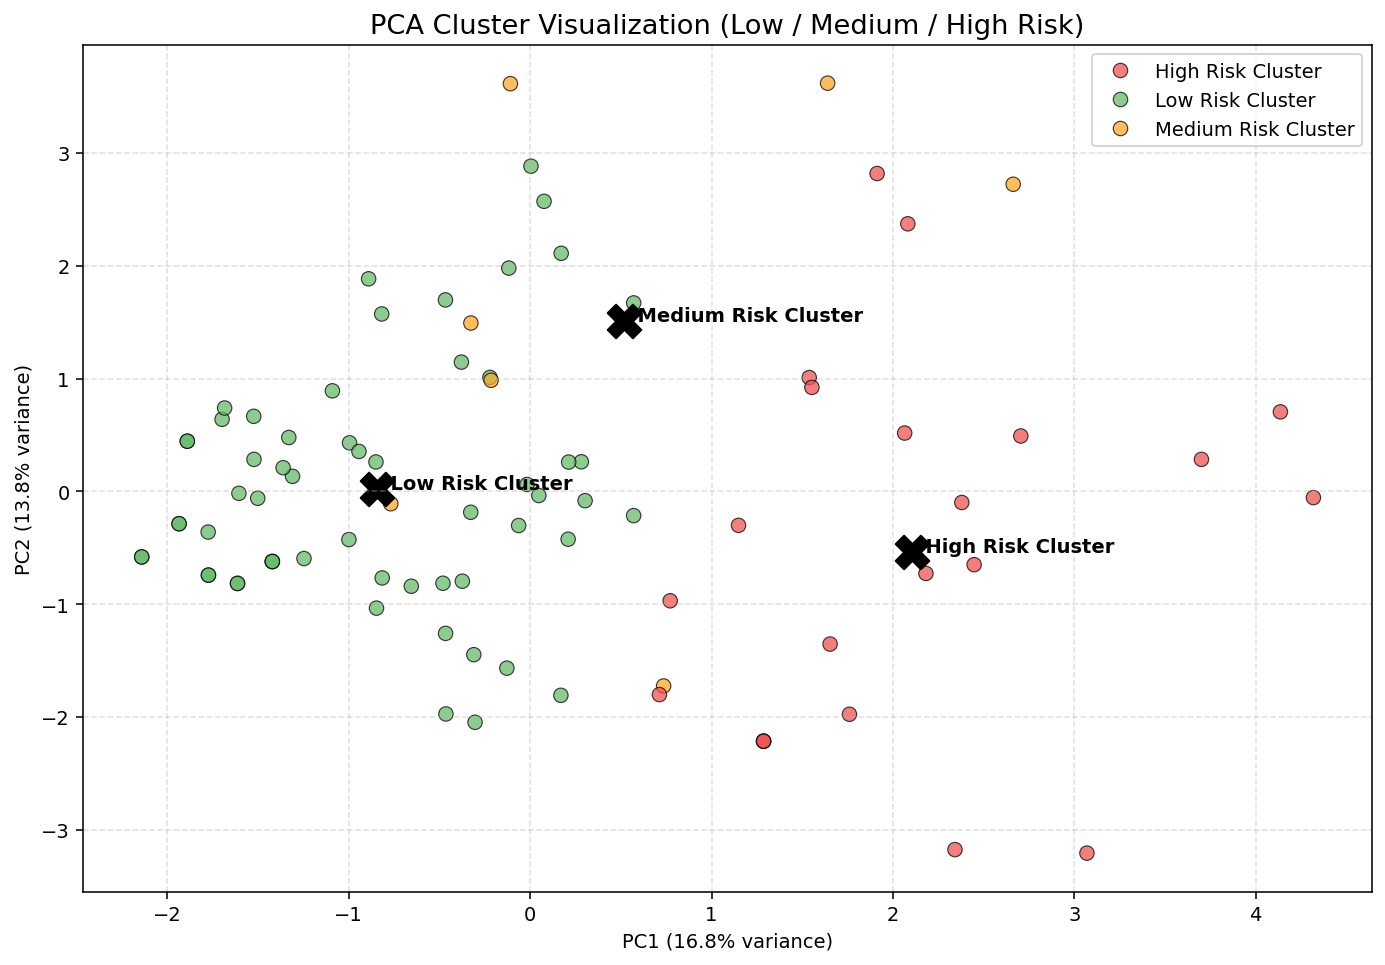


💾 Saved as: Master_Flags_Final_withClusters.csv


In [ ]:
# =========================================================
#          FULL SUBCONTRACTOR RISK MODEL PIPELINE
# =========================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 140

# ============================================================
#   2. LOAD YOUR DATA
# ============================================================
df = pd.read_excel("/content/Subcontractor_RiskModel_Output.xlsx") # Changed from pd.read_csv to pd.read_excel

print("Loaded dataset:", df.shape)

# ============================================================
#   3. SELECT FEATURES FOR CLUSTERING
# ============================================================
# Exclude ID, name, and final risk score
exclude_cols = ["company_id", "company_name", "Final_Risk_Score", "Final_Risk_Score_10pt"]

risk_features = [c for c in df.columns if c not in exclude_cols]

print("Using these columns for clustering:")
print(risk_features)

X = df[risk_features].copy()

# Convert all to numeric
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

# ============================================================
#   4. STANDARDIZE VALUES
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
#   5. KMEANS CLUSTERING (3 CLUSTERS)
# ============================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_id"] = kmeans.fit_predict(X_scaled)

# ============================================================
#   6. LABEL CLUSTERS BY RISK LEVEL
# ============================================================
cluster_means = df.groupby("cluster_id")["Final_Risk_Score_10pt"].mean().sort_values()

low_cluster    = cluster_means.index[0]
medium_cluster = cluster_means.index[1]
high_cluster   = cluster_means.index[2]

cluster_map = {
    low_cluster: "Low Risk Cluster",
    medium_cluster: "Medium Risk Cluster",
    high_cluster: "High Risk Cluster"
}

df["risk_cluster"] = df["cluster_id"].map(cluster_map)

print("Cluster sizes:\n", df["risk_cluster"].value_counts())

# ============================================================
#   7. PCA FOR VISUALIZATION
# ============================================================
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

df["PC1"] = coords[:, 0]
df["PC2"] = coords[:, 1]

# Transform centroids
centroids = pca.transform(kmeans.cluster_centers_)

# ============================================================
#   8. PCA SCATTER PLOT WITH CLUSTER COLORS + CENTROIDS
# ============================================================
palette = {
    "Low Risk Cluster": "#66BB6A",
    "Medium Risk Cluster": "#FFA726",
    "High Risk Cluster": "#EF5350"
}

plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="risk_cluster",
    data=df,
    palette=palette,
    s=55,
    alpha=0.75,
    edgecolor="black",
)

# Plot centroids
for i, (x_c, y_c) in enumerate(centroids):
    label = cluster_map[i]
    plt.scatter(x_c, y_c, c="black", s=300, marker="X")
    plt.text(x_c, y_c, f"  {label}", fontsize=10, weight="bold")

plt.title("PCA Cluster Visualization (Low / Medium / High Risk)", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
#   9. SAVE FINAL OUTPUT
# ============================================================
df.to_csv("Master_Flags_Final_withClusters.csv", index=False)
print("\n💾 Saved as: Master_Flags_Final_withClusters.csv")


Loaded: (88, 26)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


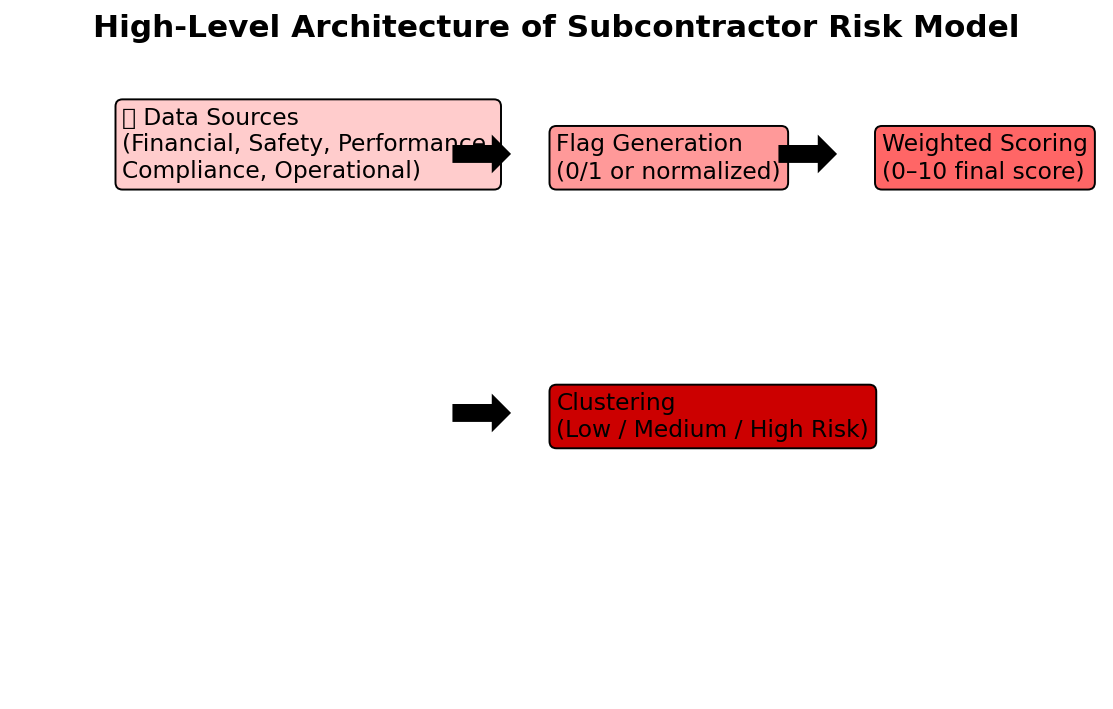

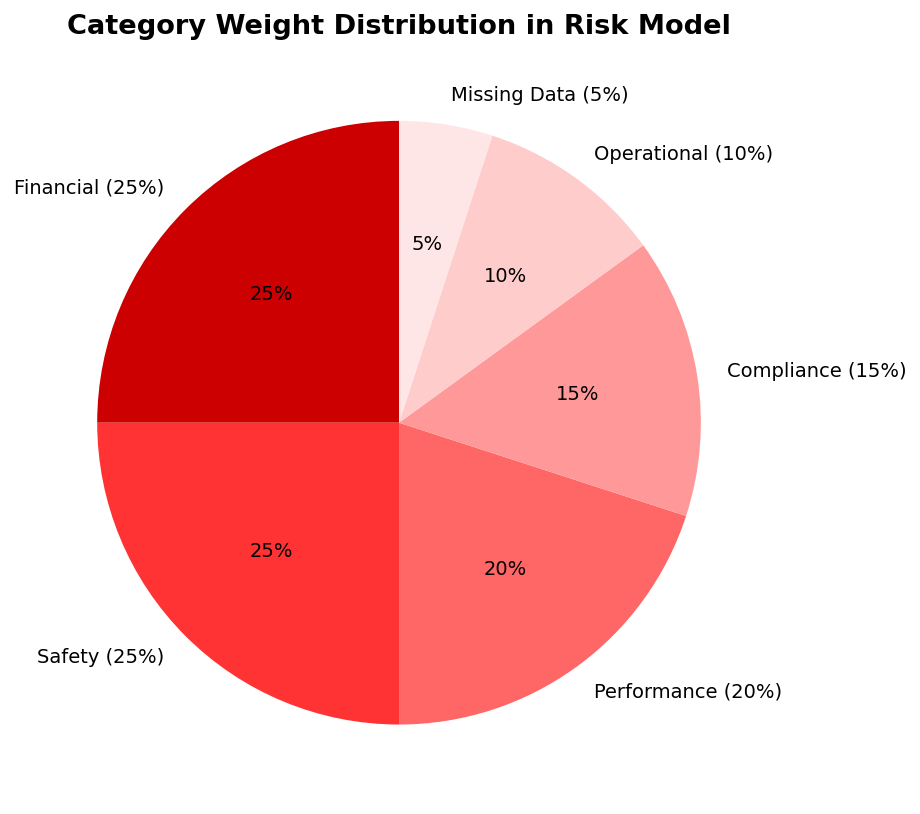

/tmp/ipython-input-3451526183.py:110: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df["Final_Risk_Score_10pt"], bins=num_bins, kde=True,


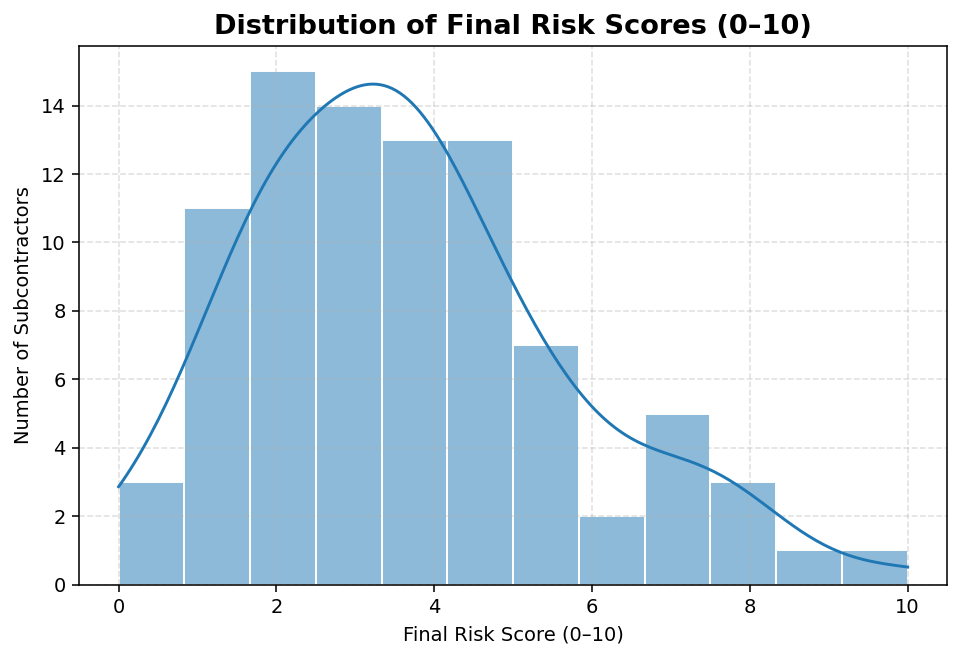

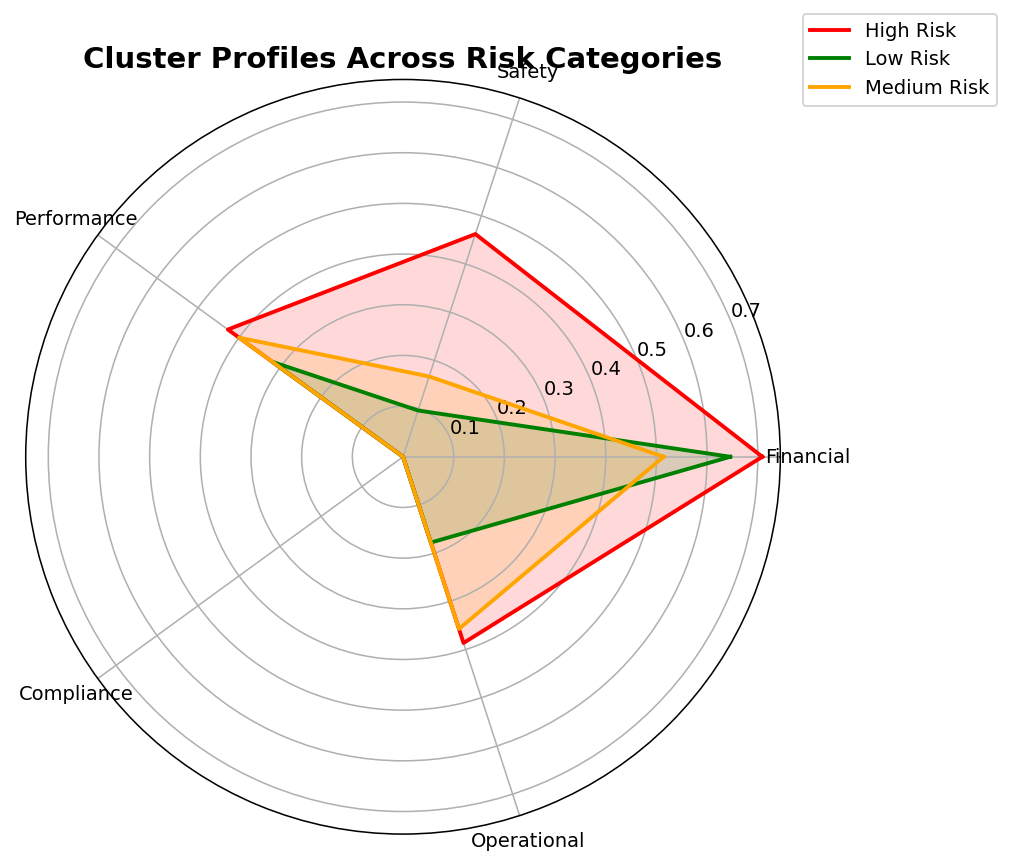

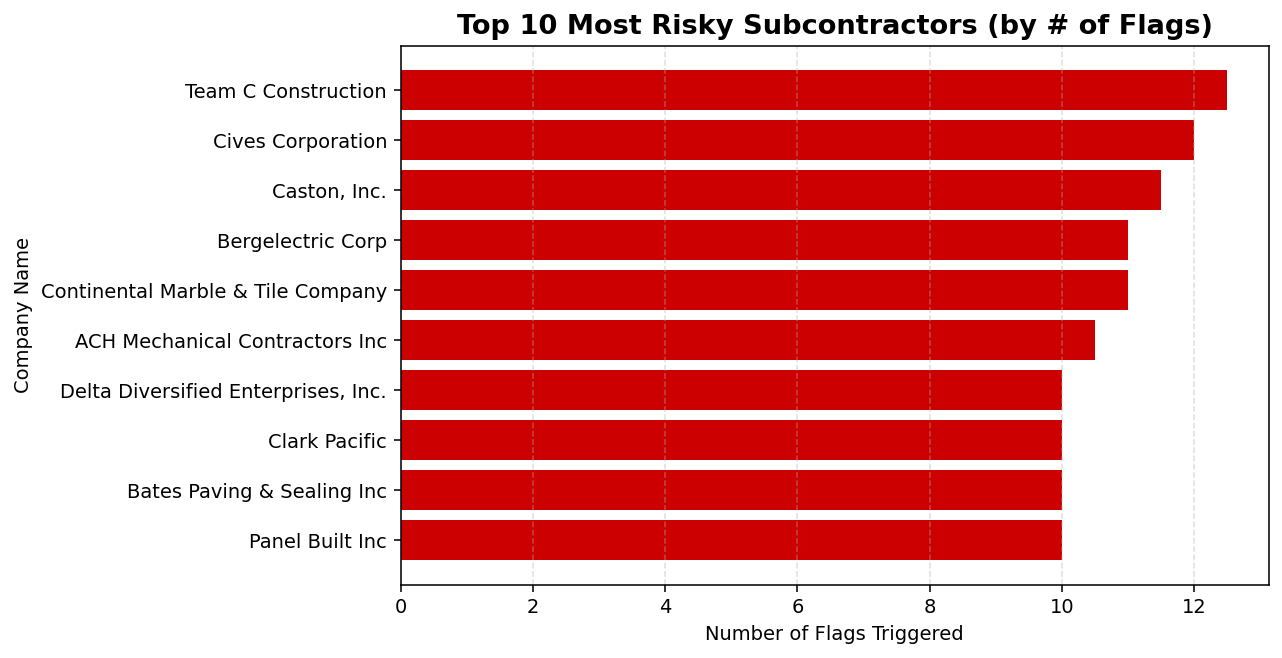

In [4]:
# ============================================================
# 0. IMPORTS
# ============================================================
!pip install matplotlib seaborn pandas numpy openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

plt.rcParams["figure.dpi"] = 140

# ============================================================
# 1. LOAD FINAL DATA
# ============================================================
df = pd.read_excel("/content/Subcontractor_RiskModel_Output_FinalScore.xlsx")

print("Loaded:", df.shape)

# ------------------------------------------------------------
# CATEGORY SCORE GROUPINGS
# ------------------------------------------------------------
financial_cols = [
    "SingleProject_Overextension_Flag",
    "Aggregate_Overextension_Flag",
    "LOC_Utilization_Grade",
    "CashFlow_Risk_Flag",
    "WorkingCapital_Coverage_Score"
]

safety_cols = [
    "osha300Results_risk_flag",
    "recordableIncidentRates_risk_flag",
    "dartRates_risk_flag",
    "emr_high_flag",
    "emr_trend_up_flag",
    "emr_missing_flag"
]

performance_cols = [
    "FieldSupervision_Adequacy_Flag",
    "BacklogPressure_Flag",
    "low_avg_score_flag",
    "low_individual_scores_flag",
    "inconsistent_reviews_flag"
]

compliance_cols = [
    "unlicensed_flag",
    "expired_qualification_flag",
    "denied_or_suspended_flag"
]

operational_cols = [
    "overloaded_vendor_flag",
    "trade_risk12_flag"
]

# ============================================================
# 2. HIGH-LEVEL ARCHITECTURE DIAGRAM
# ============================================================
# plt.figure(figsize=(10,6))
# plt.axis("off")

# plt.text(0.1, 0.8, " Data Sources\n(Financial, Safety, Performance,\nCompliance, Operational)",
#          fontsize=12, bbox=dict(boxstyle="round", fc="#FFCCCC"))

# plt.text(0.4, 0.8, "", fontsize=40)

# plt.text(0.5, 0.8, "Flag Generation\n(0/1 or normalized)",
#          fontsize=12, bbox=dict(boxstyle="round", fc="#FF9999"))

# plt.text(0.7, 0.8, "", fontsize=40)

# plt.text(0.8, 0.8, "Weighted Scoring\n(0–10 final score)",
#          fontsize=12, bbox=dict(boxstyle="round", fc="#FF6666"))

# plt.text(0.4, 0.4, "", fontsize=40)
# plt.text(0.5, 0.4, "Clustering\n(Low / Medium / High Risk)",
#          fontsize=12, bbox=dict(boxstyle="round", fc="#CC0000"))

# plt.title("High-Level Architecture of Subcontractor Risk Model", fontsize=16, weight="bold")
# plt.show()


# ============================================================
# 3. WEIGHT DISTRIBUTION PIE CHART
# ============================================================
labels = ["Financial (25%)", "Safety (25%)", "Performance (20%)",
          "Compliance (15%)", "Operational (10%)", "Missing Data (5%)"]

sizes = [25, 25, 20, 15, 10, 5]
colors = ["#CC0000","#FF3333","#FF6666","#FF9999","#FFCCCC","#FFE6E6"]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%",
        startangle=90, textprops={"fontsize": 10})
plt.title("Category Weight Distribution in Risk Model", fontsize=14, weight="bold")
plt.show()


# ============================================================
# 4. FINAL RISK SCORE HISTOGRAM (0–10)
# ============================================================
num_bins = 12
bin_colors = sns.color_palette(["#CC0000","#FF3333","#FF6666","#FF9999","#FFCCCC"], num_bins)

plt.figure(figsize=(8,5))
sns.histplot(df["Final_Risk_Score_10pt"], bins=num_bins, kde=True,
             palette=bin_colors, edgecolor="white")
plt.title("Distribution of Final Risk Scores (0–10)", fontsize=14, weight="bold")
plt.xlabel("Final Risk Score (0–10)")
plt.ylabel("Number of Subcontractors")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# ============================================================
# 5. RADAR CHART – CLUSTER PROFILES
# ============================================================

# Load existing risk cluster if available; otherwise cluster quickly
if "risk_cluster" not in df.columns:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans

    risk_cols = financial_cols + safety_cols + performance_cols + compliance_cols + operational_cols
    X = df[risk_cols].fillna(0)
    X_scaled = StandardScaler().fit_transform(X)

    model = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["cluster_id"] = model.fit_predict(X_scaled)

    # Rank clusters by average risk
    cluster_map = df.groupby("cluster_id")["Final_Risk_Score_10pt"].mean().sort_values().index.tolist()
    df["risk_cluster"] = df["cluster_id"].map({
        cluster_map[0]: "Low Risk",
        cluster_map[1]: "Medium Risk",
        cluster_map[2]: "High Risk"
    })

# Compute category means per cluster
radar_stats = {
    "Financial": df.groupby("risk_cluster")[financial_cols].mean().mean(axis=1),
    "Safety": df.groupby("risk_cluster")[safety_cols].mean().mean(axis=1),
    "Performance": df.groupby("risk_cluster")[performance_cols].mean().mean(axis=1),
    "Compliance": df.groupby("risk_cluster")[compliance_cols].mean().mean(axis=1),
    "Operational": df.groupby("risk_cluster")[operational_cols].mean().mean(axis=1)
}

radar_df = pd.DataFrame(radar_stats)

categories = radar_df.columns.tolist()
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

colors = {"Low Risk":"green","Medium Risk":"orange","High Risk":"red"}

for cluster in radar_df.index:
    values = radar_df.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=cluster, color=colors[cluster])
    ax.fill(angles, values, alpha=0.15, color=colors[cluster])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("Cluster Profiles Across Risk Categories", size=15, weight="bold")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()


# ============================================================
# 6. TOP 10 MOST RISKY SUBCONTRACTORS
# ============================================================

# Count number of triggered flags
flag_cols = financial_cols + safety_cols + performance_cols + compliance_cols + operational_cols
df["num_flags"] = df[flag_cols].sum(axis=1)

top10 = df.nlargest(10, "num_flags")[["company_name","num_flags"]]

plt.figure(figsize=(8,5))
plt.barh(top10["company_name"], top10["num_flags"], color="#CC0000")
plt.title("Top 10 Most Risky Subcontractors (by # of Flags)", fontsize=14, weight="bold")
plt.xlabel("Number of Flags Triggered")
plt.ylabel("Company Name")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

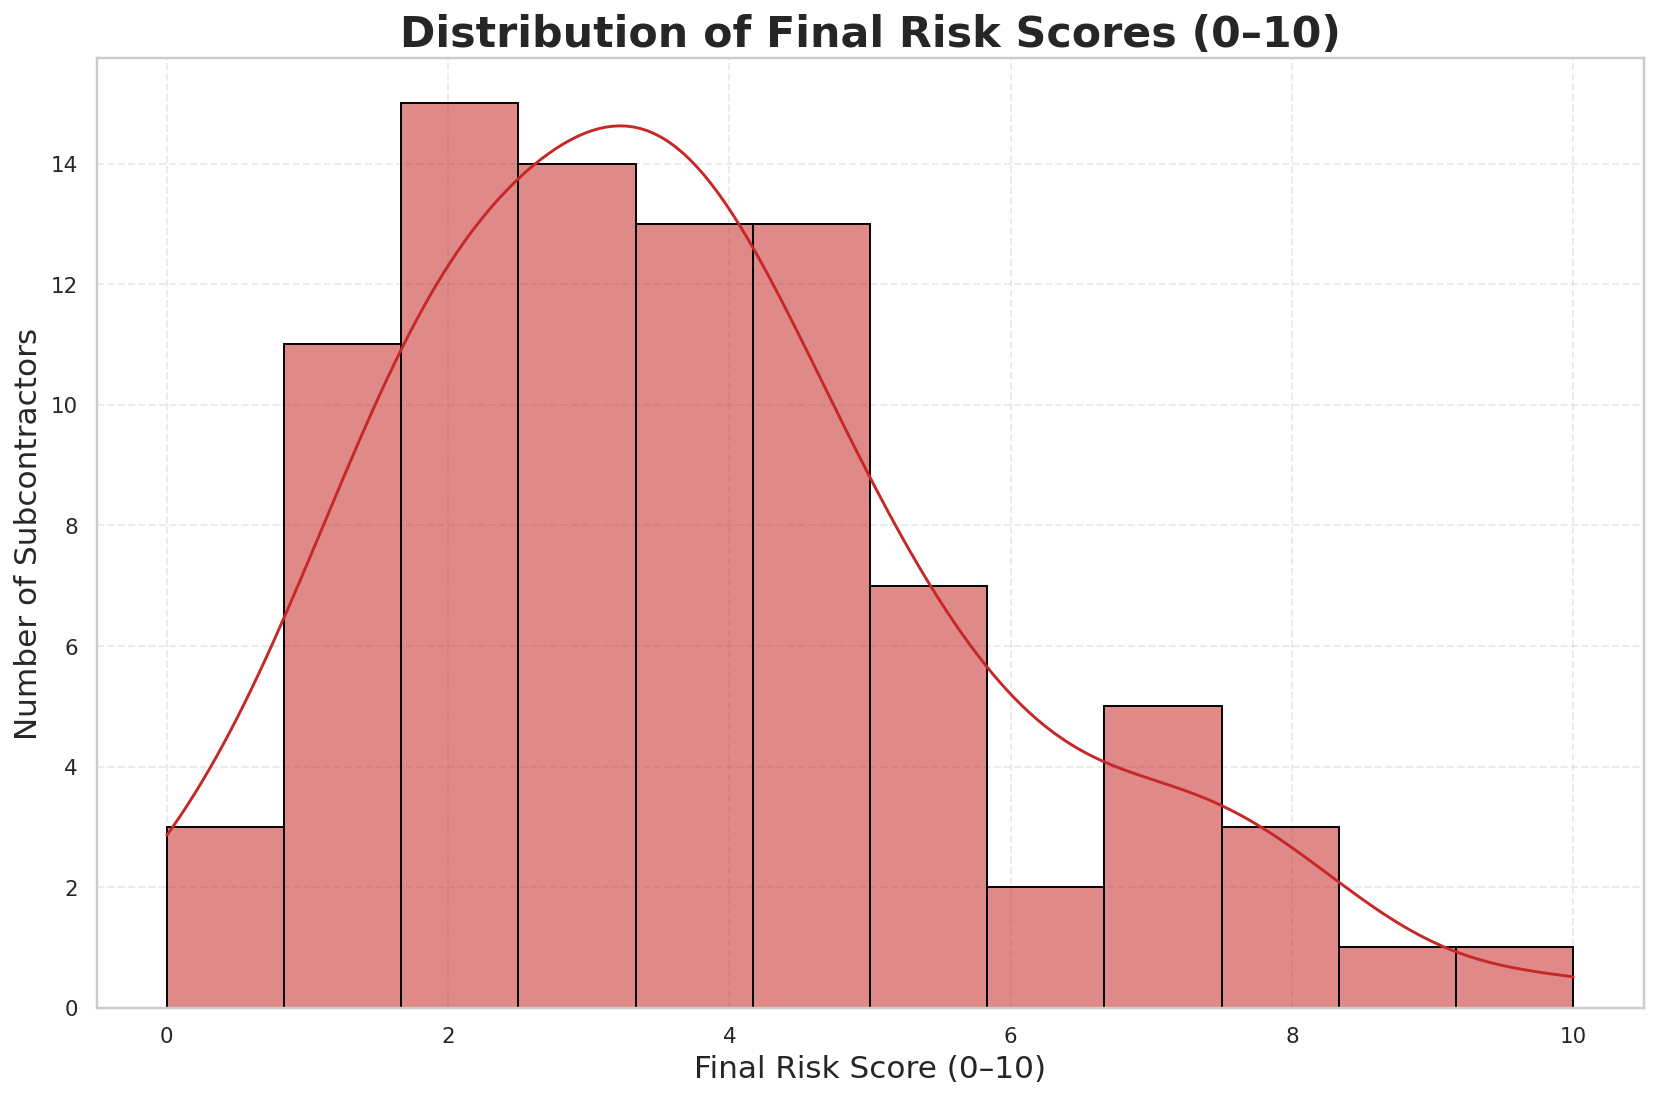

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.histplot(
    df["Final_Risk_Score_10pt"],
    bins=12,
    kde=True,
    color="#C62828",      # deep professional red
    edgecolor="black",
    alpha=0.55
)

plt.title("Distribution of Final Risk Scores (0–10)", fontsize=22, weight="bold")
plt.xlabel("Final Risk Score (0–10)", fontsize=16)
plt.ylabel("Number of Subcontractors", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

/tmp/ipython-input-917824837.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


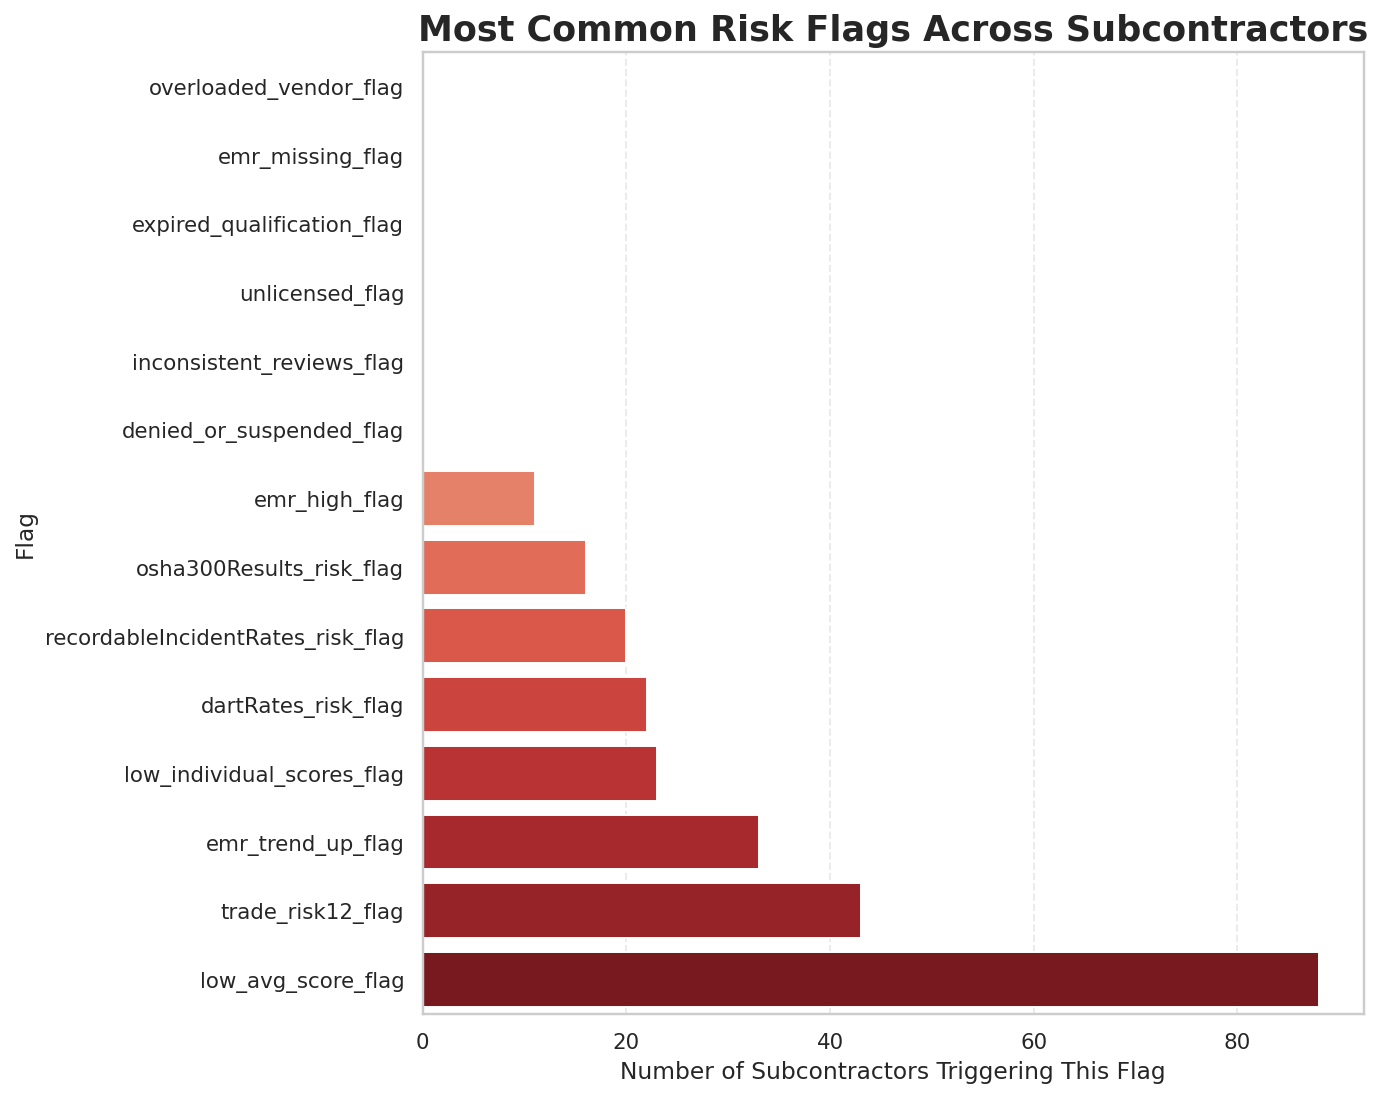

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_excel("Subcontractor_RiskModel_Output_FinalScore.xlsx")

# Extract only numeric binary flags
flag_cols = [
    c for c in df.columns
    if ("_flag" in c and c not in ["missing_key_data_flag"])
]

flag_counts = df[flag_cols].sum().sort_values(ascending=True)

plt.figure(figsize=(10,8))
sns.barplot(
    x=flag_counts.values,
    y=flag_counts.index,
    palette="Reds"
)

plt.title("Most Common Risk Flags Across Subcontractors", fontsize=18, weight="bold")
plt.xlabel("Number of Subcontractors Triggering This Flag")
plt.ylabel("Flag")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

risk_cluster
Medium    43
High      27
Low       18
Name: count, dtype: int64


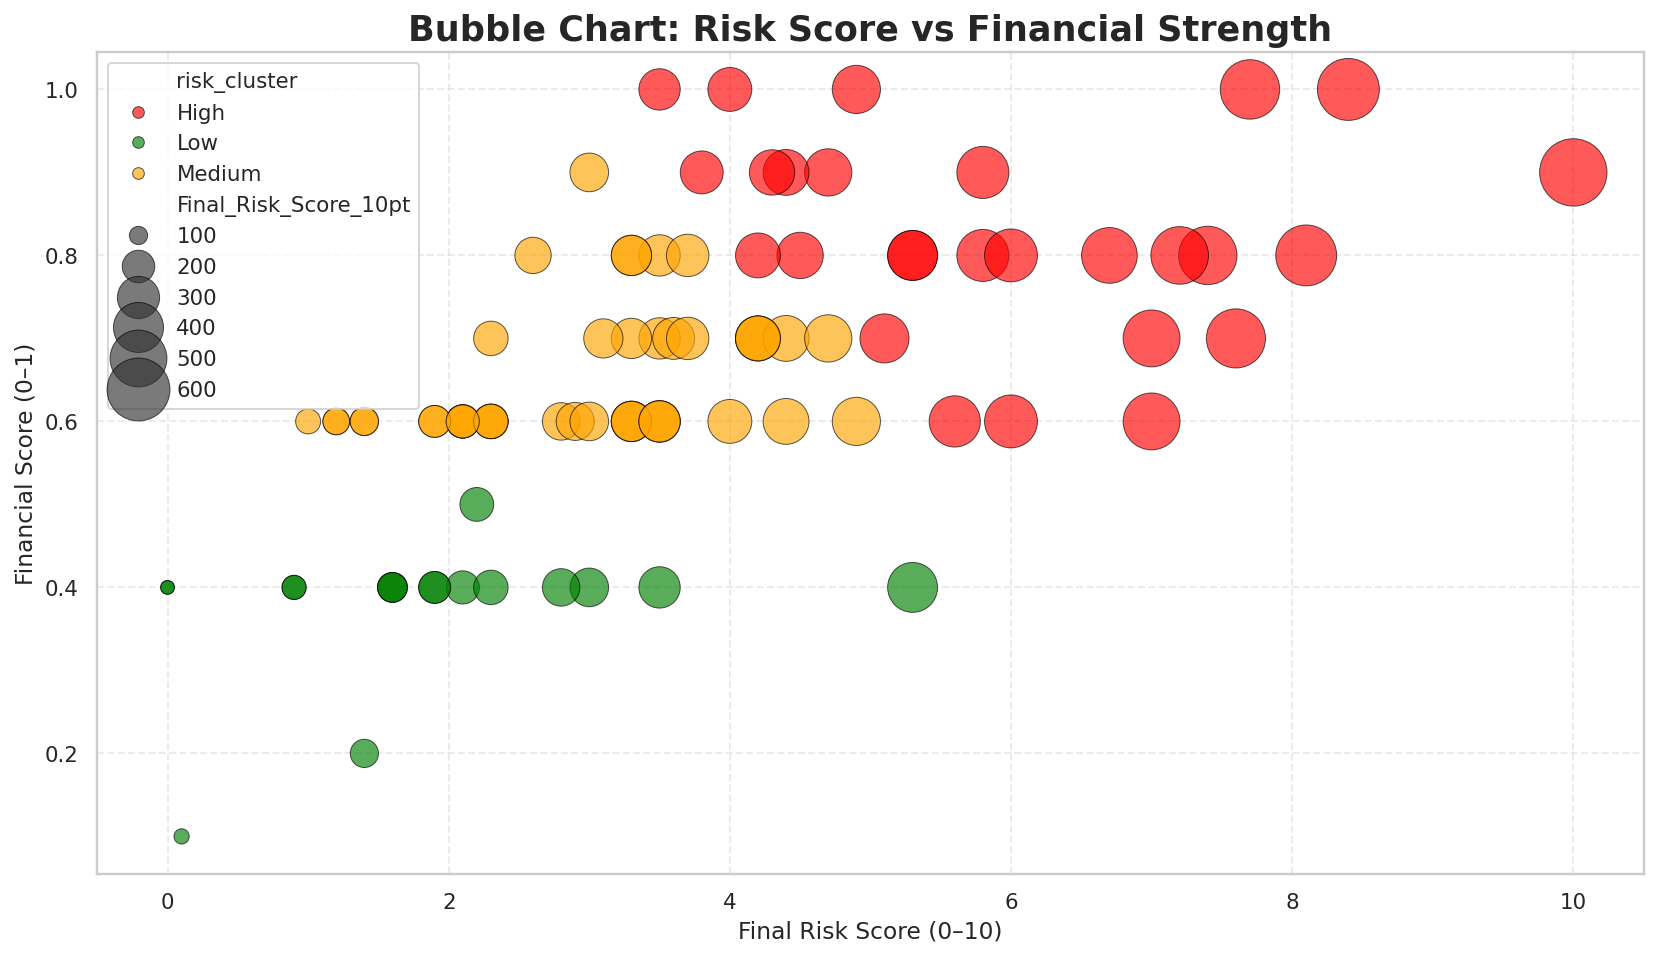

In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------------
# LOAD DATA
# --------------------------------------------------------
df = pd.read_excel("Subcontractor_RiskModel_Output_FinalScore.xlsx")

# --------------------------------------------------------
# COMPUTE FINANCIAL SCORE
# --------------------------------------------------------
df["Financial_Score"] = df[[
    "SingleProject_Overextension_Flag",
    "Aggregate_Overextension_Flag",
    "LOC_Utilization_Grade",
    "CashFlow_Risk_Flag",
    "WorkingCapital_Coverage_Score"
]].mean(axis=1)


# --------------------------------------------------------
# CREATE CLUSTERS (Low / Medium / High Risk)
# --------------------------------------------------------
X = df[["Final_Risk_Score_10pt", "Financial_Score"]].copy()

# scale values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_id"] = kmeans.fit_predict(X_scaled)

# rank clusters by risk score
cluster_risk = df.groupby("cluster_id")["Final_Risk_Score_10pt"].mean()
ranked = cluster_risk.rank().astype(int)

# map clusters
cluster_map = {
    ranked[ranked == 1].index[0]: "Low",
    ranked[ranked == 2].index[0]: "Medium",
    ranked[ranked == 3].index[0]: "High",
}
df["risk_cluster"] = df["cluster_id"].map(cluster_map)

print(df["risk_cluster"].value_counts())


# --------------------------------------------------------
# BUBBLE CHART
# --------------------------------------------------------
plt.figure(figsize=(12,7))

sizes = (df["Final_Risk_Score_10pt"] * 60) + 80  # bubble sizes

sns.scatterplot(
    data=df,
    x="Final_Risk_Score_10pt",
    y="Financial_Score",
    size=sizes,
    sizes=(50, 1200),
    hue="risk_cluster",
    palette={"Low": "green", "Medium": "orange", "High": "red"},
    alpha=0.65,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Bubble Chart: Risk Score vs Financial Strength", fontsize=18, weight="bold")
plt.xlabel("Final Risk Score (0–10)")
plt.ylabel("Financial Score (0–1)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()